# GW Turbulence — Full Workflow Demo

A self-contained walkthrough of the `gw_turbulence` library: from evaluating kernel functions
to computing and saving 2D spectral grids.  Run this notebook from the `src/` directory.

**All six H(p,q) models are demonstrated here with every parameter passed explicitly.**

In [78]:
import time
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

from gw_turbulence import (
    # Shared kernel / temporal utilities
    g_decaying,
    kernel_bracket,
    kernel_bracket_zy,
    LiveStatusLogger,
    mpi_is_active,
    # Model 1: Kolmogorov stationary (Kraichnan decorrelation)
    H_k0_analytic,
    H_pq,
    # Model 2: Kolmogorov decaying
    H_pq_decaying,
    H_pq_decaying_grid,
    # Models 3 & 4: monochromatic (delta-k) spectrum
    K0_p,
    H_delta_k_kraichnan,
    H_delta_k_kraichnan_grid,
    H_delta_k_decay,
    H_delta_k_decay_grid,
    # Models 5 & 6: white-noise (delta^3(r)) spatial correlations
    H_white_kraichnan,
    H_white_kraichnan_grid,
    H_white_decay,
    H_white_decay_grid,
    # Library plotting helpers
    plot_gogoberidze_2007_figure1,
    plot_spectra_M_analytic,
)

%matplotlib inline

out_dir = os.path.abspath('outputs')
os.makedirs(out_dir, exist_ok=True)
print('MPI active:', mpi_is_active())

MPI active: False


## 1. Core kernel functions

Two low-level building blocks are shared across all models:

**`g_decaying(z)`** — dimensionless temporal kernel for the decaying-spectrum model:
$$g(z) = e^{iz}(-iz)^{-5/3}\,\Gamma\!\left(\tfrac{1}{3},\,-iz\right), \qquad z = \omega\tau_1$$
where $\Gamma(a,w)$ is the *lower* incomplete gamma function (mpmath convention).
Hermitian symmetry: $g(-z) = g^*(z)$.

**`kernel_bracket(p, x, y)`** — geometric projection factor in Gogoberidze $(x,y)$ variables ($x = (k_1/k_0)^{-4/3}$, $y = (u/k_0)^{-4/3}$, $p = k/k_0$):
$$\mathcal{K}(p,x,y) = 54 - 2p^2 x^{3/2} - 2p^2 y^{3/2} + p^4 x^{3/2}y^{3/2} + x^{-3/2}y^{3/2} + y^{-3/2}x^{3/2}$$

**`kernel_bracket_zy(p, z, y)`** — same kernel in direct $(z = k_1/k_0,\,y = u/k_0)$ variables:
$$\mathcal{K}(p,z,y) = 54 - 2p^2/z^2 - 2p^2/y^2 + p^4/(z^2 y^2) + z^2/y^2 + y^2/z^2$$

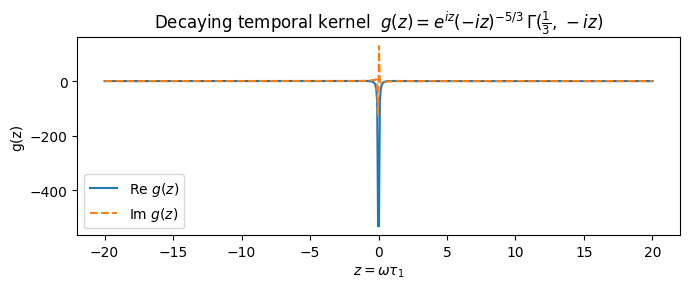

Hermitian symmetry g(-z) == conj(g(z)): True
max |g|: 548.5102

kernel_bracket   (p=1.0, x=0.3969, y=0.5824) = 55.062500
kernel_bracket_zy(p=1.0, z=2.0, y=1.5)       = 55.062500
Agree: True
K0_p(p=0.5) = 4.588542
K0_p(p=1.0) = 4.416667
K0_p(p=1.5) = 4.338542
K0_p(p=2.0) = 4.666667


In [79]:
# ── g_decaying ──────────────────────────────────────────────────────────────
z = np.linspace(-20, 20, 600)
gz = g_decaying(z)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(z, gz.real, label=r'Re $g(z)$')
ax.plot(z, gz.imag, label=r'Im $g(z)$', linestyle='--')
ax.set_xlabel(r'$z = \omega\tau_1$')
ax.set_ylabel('g(z)')
ax.set_title(r'Decaying temporal kernel  $g(z) = e^{iz}(-iz)^{-5/3}\,\Gamma(\frac{1}{3},\,-iz)$')
ax.legend()
fig.tight_layout()
plt.show()

print(f'Hermitian symmetry g(-z) == conj(g(z)): {np.allclose(g_decaying(-z), np.conj(gz))}')
print(f'max |g|: {np.abs(gz).max():.4f}')

# ── Geometric kernel consistency check ──────────────────────────────────────
# Both kernel_bracket and kernel_bracket_zy return the same number when
# x = z^{-4/3} so that x^{3/2} = z^{-2}.
p_t, z_t, y_t = 1.0, 2.0, 1.5
x_t = z_t ** (-4.0 / 3.0)   # Gogoberidze substitution
y_x_t = y_t ** (-4.0 / 3.0)
kb  = kernel_bracket(p_t, x_t, y_x_t)
kbz = kernel_bracket_zy(p_t, z_t, y_t)
print(f'\nkernel_bracket   (p={p_t}, x={x_t:.4f}, y={y_x_t:.4f}) = {kb:.6f}')
print(f'kernel_bracket_zy(p={p_t}, z={z_t}, y={y_t})       = {kbz:.6f}')
print(f'Agree: {abs(kb - kbz) < 1e-10}')

# Monochromatic geometric factor K0(p) = kernel at k1=u=k0 (z=y=1)
for p_val in [0.5, 1.0, 1.5, 2.0]:
    print(f'K0_p(p={p_val}) = {K0_p(p_val):.6f}')

## 2. All H(p,q) cases — model overview

The library implements **six models** organised along two axes:

| | Kraichnan (stationary) temporal | Decaying temporal |
|---|---|---|
| **Kolmogorov** $E(k)\propto k^{-5/3}$ | `H_pq` | `H_pq_decaying` |
| **Monochromatic** $E=E_0\delta(k-k_0)$ | `H_delta_k_kraichnan` | `H_delta_k_decay` |
| **White-noise** $R_{ij}\propto\delta^3(r)$ | `H_white_kraichnan` | `H_white_decay` |

---

### Model 1 — Kolmogorov stationary  `H_pq(p, q, M, R, k0, epsabs, epsrel)`

Full double integral over wavevector magnitudes with analytic temporal convolution via erfc:

$$H(p,q) = \frac{3M^3 k_0^{-4}}{256(2\pi)^{3/2}p}
\int_{R^{-1}}^{1} dx\int dy\;
\frac{x^{3/4}y^{3/4}}{\sqrt{x+y}}\,\mathcal{K}(p,x,y)\,
e^{-\frac{2xy}{x+y}\frac{q^2}{M^2}}\,
\mathrm{erfc}\!\left(-\frac{\sqrt{2}\,q}{M\sqrt{x+y}}\right)$$

- $p = k/k_0$, $q = \omega/k_0$, $M$ = Mach number, $R = k_{\max}/k_0$ (inertial-range ratio)
- $x$-integration bounds: $[R^{-1},\,1]$; $y$-bounds from triangle inequality

---

### Model 2 — Kolmogorov decaying  `H_pq_decaying(p, q, M, R, k0, epsabs, epsrel, convolution_method, convolution_points, integration_method, x_points, y_points)`

Same wavevector structure but the Gaussian temporal factor is replaced by the numerical
convolution $\int dq_1\,\mathrm{Re}[g(q_1\sqrt{x}/M)\,g((q-q_1)\sqrt{y}/M)]$:

$$H(p,q) = \frac{3M^3 k_0^{-4}}{256(2\pi)^{3/2}p}
\int_{R^{-1}}^{1} dx\int dy\;
\frac{x^{3/4}y^{3/4}}{\sqrt{x+y}}\,\mathcal{K}(p,x,y)\,
\int dq_1\,\mathrm{Re}\bigl[g\!\left(q_1\tfrac{\sqrt{x}}{M}\right)g\!\left((q-q_1)\tfrac{\sqrt{y}}{M}\right)\bigr]$$

- `convolution_method`: `'trapz'` (cosine-spaced grid) or `'quad'` (adaptive)
- `convolution_points`: grid size for `'trapz'`
- `integration_method`: `'sampled'` (geomspace + trapz) or `'quad'` (adaptive) for $(x,y)$ integrals
- `x_points`, `y_points`: grid sizes when `integration_method='sampled'`

---

### Model 3 — Delta-k Kraichnan  `H_delta_k_kraichnan(p, Omega)`

Monochromatic energy spectrum $E = E_0\delta(k-k_0)$: the $k_1$ and $u$ integrals collapse
to $k_1 = u = k_0$, giving a fully closed-form result:

$$H(p,\Omega) = \frac{K_0(p)}{p}\,\Theta(2-p)\,e^{-\Omega^2/(2\pi)}$$

where $K_0(p) = \tfrac{14}{3} - \tfrac{p^2}{3} + \tfrac{p^4}{12}$,
$\Theta(2-p)$ encodes the triangle inequality $k \le 2k_0$,
and $\Omega = \omega/\eta_0$ (frequency in units of the eddy-turnover rate $\eta_0$).
**No numerical integration required.**

---

### Model 4 — Delta-k decay  `H_delta_k_decay(p, q, n_points)`

Monochromatic spectrum with decaying temporal model — only the 1-D temporal
convolution remains:

$$H(p,q) = \frac{K_0(p)}{p}\,\Theta(2-p)\,\int dq_1\,\mathrm{Re}[g(q_1)\,g(q-q_1)]$$

where $q = \omega\tau_1$.  `n_points` sets the cosine-grid size for the trapz convolution.

---

### Model 5 — White-noise Kraichnan  `H_white_kraichnan(p, Omega, R, epsabs, epsrel)`

Spatial correlations $\propto\delta^3(\mathbf{r})$, Kraichnan temporal:

$$H(p,\Omega) = e^{-\Omega^2/(2\pi)}\,S(p,R), \qquad
S(p,R) = \int_1^{R^{3/4}} \frac{z}{p}\,dz \int_{\max(|p-z|,1)}^{\min(p+z,R^{3/4})} y\,dy\;
\mathcal{K}_{zy}(p,z,y)$$

The spatial factor $S(p,R)$ is independent of $\Omega$ and precomputed via 2-D `quad`.

---

### Model 6 — White-noise decay  `H_white_decay(p, q, R, epsabs, epsrel, n_points)`

White-noise spatial correlations with decaying temporal model:

$$H(p,q) = S(p,R)\,\int dq_1\,\mathrm{Re}[g(q_1)\,g(q-q_1)]$$

The two factors are independent and computed separately, allowing caching when
sweeping either variable.

## 3. Analytic $p\to 0$ spectrum (stationary, fast)

`H_k0_analytic(q, M, k0, R)` is the closed-form $p\to 0$ limit of Model 1, obtained by
integrating only over $x$ with $y$ collapsed:

$$H(0, q) = \frac{7M^3 k_0^{-4}}{16\pi^{3/2}}
\int_{R^{-1}}^{1} dx\; x^{11/4}\,e^{-(q/M)^2 x}\,
\mathrm{erfc}\!\left(-\frac{q}{M}\sqrt{x}\right)$$

**Parameters:** `q` (scalar or array), `M` (Mach number), `k0` (pivot wavenumber), `R` (inertial-range ratio).

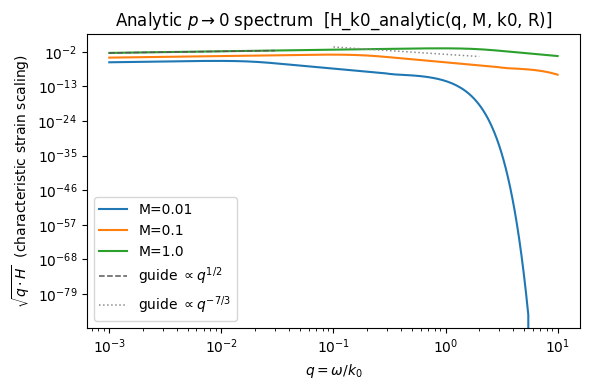

In [80]:
M_list = [0.01, 0.1, 1.0]
k0     = 1.0
R      = 1e4
qs_analytic = np.logspace(-3, 1, 200)

fig, ax = plt.subplots(figsize=(6, 4))
for M in M_list:
    H = H_k0_analytic(qs_analytic, M=M, k0=k0, R=R)
    ax.loglog(qs_analytic, np.sqrt(qs_analytic * H), label=f'M={M}')


# ── Guiding power-law slopes ─────────────────────────────────────────────────
# Anchor on M=1.0 curve for visibility
_q_anch = 3e-3          # low-q anchor (causality slope)
_H_anch = H_k0_analytic(_q_anch, M=1.0, k0=k0, R=R)
_y0     = np.sqrt(_q_anch * _H_anch)

_ql_c = np.array([1e-3, 3e-2])               # causality range
ax.loglog(_ql_c, _y0 * (_ql_c / _q_anch) ** 0.5,
          color='0.35', lw=1.1, ls='--', label=r'guide $\propto q^{1/2}$')

_q_ir_anch = 2e-1        # inertial-range anchor (on M=1.0)
_H_ir      = H_k0_analytic(_q_ir_anch, M=1.0, k0=k0, R=R)
_y_ir      = np.sqrt(_q_ir_anch * _H_ir)
_ql_ir = np.array([1e-1, 2e0])
ax.loglog(_ql_ir, _y_ir * (_ql_ir / _q_ir_anch) ** (-7/3),
          color='0.55', lw=1.1, ls=':', label=r'guide $\propto q^{-7/3}$')
ax.set_xlabel(r'$q = \omega/k_0$')
ax.set_ylabel(r'$\sqrt{q\cdot H}$  (characteristic strain scaling)')
ax.set_title(r'Analytic $p\to 0$ spectrum  [H_k0_analytic(q, M, k0, R)]')
ax.legend()
fig.tight_layout()
plt.show()

## 4. Single-point evaluation — all six cases

Below we compute one point for each model, with **every parameter named explicitly**.

Note the different frequency-variable conventions:

| Model | Frequency variable | Meaning |
|---|---|---|
| `H_pq`, `H_pq_decaying` | $q = \omega/k_0$ | frequency in units of pivot wavenumber |
| `H_delta_k_kraichnan`, `H_white_kraichnan` | $\Omega = \omega/\eta_0$ | frequency in units of eddy-turnover rate |
| `H_delta_k_decay`, `H_white_decay` | $q = \omega\tau_1$ | frequency × decay time |

In [81]:
# ── Model 1: Kolmogorov stationary (Kraichnan) ───────────────────────────────
p_kol   = 0.5
q_kol   = 0.3
M_kol   = 0.1
R_kol   = 1e3
k0_kol  = 1.0
eps_abs_kol = 5e-4
eps_rel_kol = 3e-3

t0 = time.perf_counter()
H_stat = H_pq(
    p_kol, q_kol,
    M=M_kol, R=R_kol, k0=k0_kol,
    epsabs=eps_abs_kol, epsrel=eps_rel_kol,
)
t_stat = time.perf_counter() - t0

# ── Model 2: Kolmogorov decaying ─────────────────────────────────────────────
M_dec            = 0.1
R_dec            = 1e3
k0_dec           = 1.0
eps_abs_dec      = 2e-3
eps_rel_dec      = 1e-2
conv_method_dec  = 'trapz'
conv_points_dec  = 32
integ_method_dec = 'sampled'
x_pts_dec        = 12
y_pts_dec        = 12

status_dec = LiveStatusLogger(
    prefix='single-pt', every_seconds=0.0,
    rank=0, root_only=True,
)
t0 = time.perf_counter()
H_dec = H_pq_decaying(
    p_kol, q_kol,
    M=M_dec, R=R_dec, k0=k0_dec,
    epsabs=eps_abs_dec, epsrel=eps_rel_dec,
    convolution_method=conv_method_dec, convolution_points=conv_points_dec,
    integration_method=integ_method_dec, x_points=x_pts_dec, y_points=y_pts_dec,
    status=status_dec,
)
t_dec = time.perf_counter() - t0

# ── Model 3: Delta-k Kraichnan  (fully closed-form) ──────────────────────────
p_dk    = 1.0
Omega_dk = 0.5     # Omega = omega / eta0

t0 = time.perf_counter()
H_dk_k = H_delta_k_kraichnan(p_dk, Omega_dk)
t_dk_k = time.perf_counter() - t0

# ── Model 4: Delta-k decay ───────────────────────────────────────────────────
q_dk_dec  = 0.5    # q = omega * tau1
n_pts_dk  = 200

t0 = time.perf_counter()
H_dk_d = H_delta_k_decay(p_dk, q_dk_dec, n_points=n_pts_dk)
t_dk_d = time.perf_counter() - t0

# ── Model 5: White-noise Kraichnan ───────────────────────────────────────────
p_wh      = 0.5
Omega_wh  = 0.5    # Omega = omega / eta0
R_wh      = 1e4
eps_abs_wh = 1e-4
eps_rel_wh = 1e-3

t0 = time.perf_counter()
H_wh_k = H_white_kraichnan(
    p_wh, Omega_wh,
    R=R_wh, epsabs=eps_abs_wh, epsrel=eps_rel_wh,
)
t_wh_k = time.perf_counter() - t0

# ── Model 6: White-noise decay ───────────────────────────────────────────────
q_wh_dec  = 0.5    # q = omega * tau1
n_pts_wh  = 200

t0 = time.perf_counter()
H_wh_d = H_white_decay(
    p_wh, q_wh_dec,
    R=R_wh, epsabs=eps_abs_wh, epsrel=eps_rel_wh, n_points=n_pts_wh,
)
t_wh_d = time.perf_counter() - t0

# ── Summary ──────────────────────────────────────────────────────────────────
print('Model                     |  H value       |  time (s)')
print('─' * 56)
print(f'H_pq               (p={p_kol}, q={q_kol})  | {H_stat:.6g}  | {t_stat:.3f}')
print(f'H_pq_decaying      (p={p_kol}, q={q_kol})  | {H_dec:.6g}  | {t_dec:.3f}')
print(f'H_delta_k_kraichnan(p={p_dk}, Ω={Omega_dk})    | {H_dk_k:.6g}  | {t_dk_k:.3f}')
print(f'H_delta_k_decay    (p={p_dk}, q={q_dk_dec})    | {H_dk_d:.6g}  | {t_dk_d:.3f}')
print(f'H_white_kraichnan  (p={p_wh}, Ω={Omega_wh})    | {H_wh_k:.6g}  | {t_wh_k:.3f}')
print(f'H_white_decay      (p={p_wh}, q={q_wh_dec})    | {H_wh_d:.6g}  | {t_wh_d:.3f}')

[single-pt] start H_pq_decaying p=5.000e-01 q=3.000e-01 M=1.000e-01 conv=trapz integ=sampled
[single-pt]   x-step 1/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 2/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 3/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 4/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 5/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 6/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 7/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 8/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 9/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 10/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 11/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 12/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 13/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 14/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 15/16 for p=5.000e-01, q=3.000e-01
[single-pt]   x-step 16/16 for p=5.000e-01, q=3.000e-01
[single-pt] done H_p

## 5. Coarse 2D grids — Kolmogorov models

Both Kolmogorov models (`H_pq` and `H_pq_decaying_grid`) share the same
$(p,q)$ axes with $p = k/k_0$ and $q = \omega/k_0$.

In [82]:
ps_kol = np.logspace(-2, 0, 8)
qs_kol = np.logspace(-2, 0, 8)
M_grid    = 0.1
R_grid    = 100.0
k0_grid   = 1.0
eps_abs_grid = 5e-4
eps_rel_grid = 3e-3

# Stationary grid (loop over H_pq)
H_stationary = np.zeros((len(qs_kol), len(ps_kol)))
for i, q in enumerate(qs_kol):
    for j, p in enumerate(ps_kol):
        H_stationary[i, j] = H_pq(
            p, q,
            M=M_grid, R=R_grid, k0=k0_grid,
            epsabs=eps_abs_grid, epsrel=eps_rel_grid,
        )
print('Stationary grid done.')

# Decaying grid (H_pq_decaying_grid with explicit params)
status_grid = LiveStatusLogger(
    prefix='coarse-grid', every_seconds=2.0,
    rank=0, root_only=True,
)
H_decaying = H_pq_decaying_grid(
    ps_kol, qs_kol,
    M=M_grid, R=R_grid, k0=k0_grid,
    epsabs=eps_abs_grid, epsrel=eps_rel_grid,
    verbose=True,
    convolution_method='trapz', convolution_points=32,
    integration_method='sampled', x_points=12, y_points=12,
    status=status_grid, log_points=True,
    use_mpi=False, processes=8,
)
print('Decaying grid done.')

Stationary grid done.
[coarse-grid] grid start rows=8 cols=8 M=1.000e-01 method=trapz points=32 rank=1/1
[coarse-grid] using multiprocessing with 8 workers
[coarse-grid] row 7/8 complete
[coarse-grid] row 8/8 complete
[coarse-grid] row 3/8 complete
[coarse-grid] row 4/8 complete
[coarse-grid] row 1/8 complete
[coarse-grid] row 6/8 complete
[coarse-grid] row 2/8 complete
[coarse-grid] row 5/8 complete
[coarse-grid] grid complete
Decaying grid done.


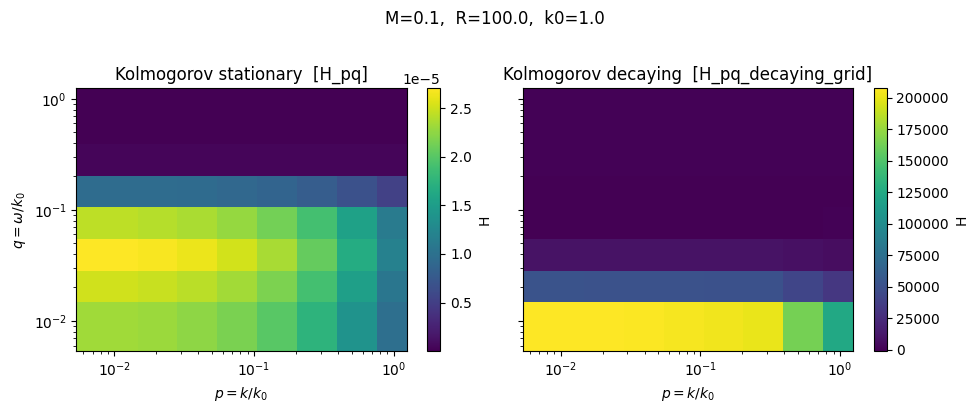

In [83]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

pcm1 = ax1.pcolormesh(ps_kol, qs_kol, H_stationary, shading='auto', cmap='viridis')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel(r'$p = k/k_0$'); ax1.set_ylabel(r'$q = \omega/k_0$')
ax1.set_title(r'Kolmogorov stationary  [H_pq]')
fig.colorbar(pcm1, ax=ax1, label='H')

pcm2 = ax2.pcolormesh(ps_kol, qs_kol, H_decaying, shading='auto', cmap='viridis')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel(r'$p = k/k_0$')
ax2.set_title(r'Kolmogorov decaying  [H_pq_decaying_grid]')
fig.colorbar(pcm2, ax=ax2, label='H')

fig.suptitle(f'M={M_grid},  R={R_grid},  k0={k0_grid}', y=1.02)
fig.tight_layout()
plt.show()

## 6. Delta-k (monochromatic) 2D grids

For $E = E_0\delta(k-k_0)$ the triangle inequality forces $p\le 2$,
so the $p$-axis spans $(0, 2]$.

**Kraichnan case** (`H_delta_k_kraichnan_grid`): fully vectorised, no integration needed.

**Decay case** (`H_delta_k_decay_grid`): computes the temporal convolution
$\int dq_1\,g(q_1)g(q-q_1)$ once per $q$, then broadcasts over all $p$.

Frequency axes:
- Kraichnan: $\Omega = \omega/\eta_0$
- Decay: $q = \omega\tau_1$

H_delta_k_kraichnan_grid shape: (20, 16)
[dk-grid] H_delta_k_decay_grid q=0.0000e+00 (1/20)
[dk-grid] H_delta_k_decay_grid q=2.6316e-01 (2/20)
[dk-grid] H_delta_k_decay_grid q=5.2632e-01 (3/20)
[dk-grid] H_delta_k_decay_grid q=7.8947e-01 (4/20)
[dk-grid] H_delta_k_decay_grid q=1.0526e+00 (5/20)
[dk-grid] H_delta_k_decay_grid q=1.3158e+00 (6/20)
[dk-grid] H_delta_k_decay_grid q=1.5789e+00 (7/20)
[dk-grid] H_delta_k_decay_grid q=1.8421e+00 (8/20)
[dk-grid] H_delta_k_decay_grid q=2.1053e+00 (9/20)
[dk-grid] H_delta_k_decay_grid q=2.3684e+00 (10/20)
[dk-grid] H_delta_k_decay_grid q=2.6316e+00 (11/20)
[dk-grid] H_delta_k_decay_grid q=2.8947e+00 (12/20)
[dk-grid] H_delta_k_decay_grid q=3.1579e+00 (13/20)
[dk-grid] H_delta_k_decay_grid q=3.4211e+00 (14/20)
[dk-grid] H_delta_k_decay_grid q=3.6842e+00 (15/20)
[dk-grid] H_delta_k_decay_grid q=3.9474e+00 (16/20)
[dk-grid] H_delta_k_decay_grid q=4.2105e+00 (17/20)
[dk-grid] H_delta_k_decay_grid q=4.4737e+00 (18/20)
[dk-grid] H_delta_k_decay_grid q

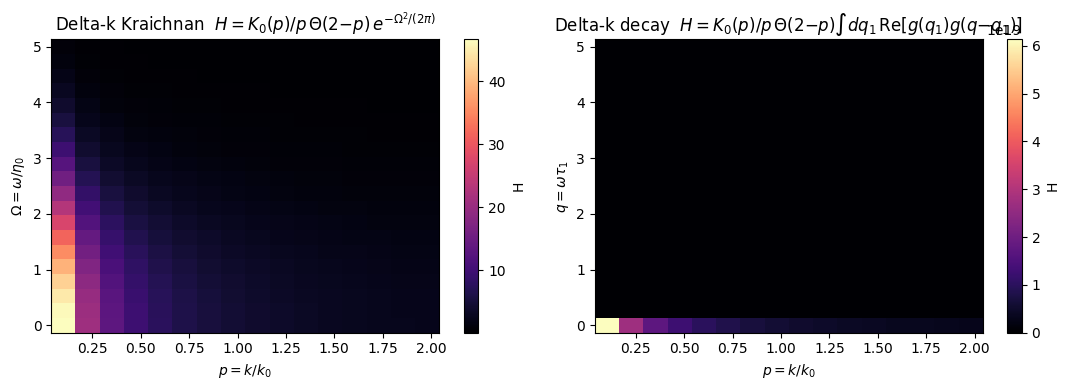

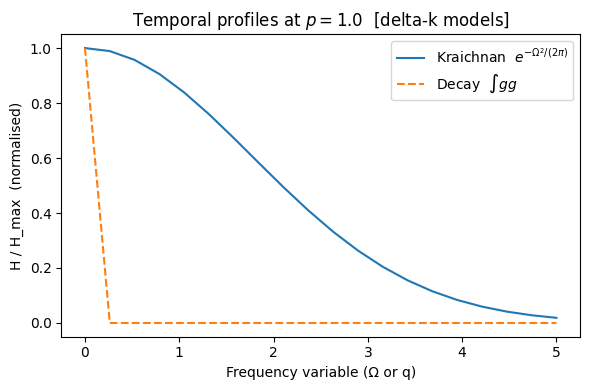

In [84]:
ps_dk     = np.linspace(0.1, 1.98, 16)   # p in (0, 2] for monochromatic model
Omegas_dk = np.linspace(0.0, 5.0, 20)    # Omega = omega/eta0  (Kraichnan)
qs_dk     = np.linspace(0.0, 5.0, 20)    # q = omega*tau1      (decay)
n_pts_dk  = 200

status_dk = LiveStatusLogger(
    prefix='dk-grid', every_seconds=1.0,
    rank=0, root_only=True,
)

# Model 3: Delta-k Kraichnan  (vectorised — no loops)
H_dk_kraichnan = H_delta_k_kraichnan_grid(ps_dk, Omegas_dk)
print(f'H_delta_k_kraichnan_grid shape: {H_dk_kraichnan.shape}')

# Model 4: Delta-k decay  (1-D conv per q, broadcast over p)
H_dk_decay = H_delta_k_decay_grid(
    ps_dk, qs_dk,
    n_points=n_pts_dk,
    status=status_dk,
)
print(f'H_delta_k_decay_grid     shape: {H_dk_decay.shape}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

pcm1 = ax1.pcolormesh(ps_dk, Omegas_dk, H_dk_kraichnan, shading='auto', cmap='magma')
ax1.set_xlabel(r'$p = k/k_0$')
ax1.set_ylabel(r'$\Omega = \omega/\eta_0$')
ax1.set_title(r'Delta-k Kraichnan  $H = K_0(p)/p\,\Theta(2{-}p)\,e^{-\Omega^2/(2\pi)}$')
fig.colorbar(pcm1, ax=ax1, label='H')

pcm2 = ax2.pcolormesh(ps_dk, qs_dk, H_dk_decay, shading='auto', cmap='magma')
ax2.set_xlabel(r'$p = k/k_0$')
ax2.set_ylabel(r'$q = \omega\tau_1$')
ax2.set_title(r'Delta-k decay  $H = K_0(p)/p\,\Theta(2{-}p)\int dq_1\,\mathrm{Re}[g(q_1)g(q{-}q_1)]$')
fig.colorbar(pcm2, ax=ax2, label='H')

fig.tight_layout()
plt.show()

# Frequency slices at p=1 to compare temporal shapes
p_slice = 1.0
H_dk_k_slice = H_delta_k_kraichnan(
    np.full_like(Omegas_dk, p_slice), Omegas_dk,
)
H_dk_d_slice = np.array([
    H_delta_k_decay(p_slice, q, n_points=n_pts_dk) for q in qs_dk
])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Omegas_dk, H_dk_k_slice / H_dk_k_slice.max(), label=r'Kraichnan  $e^{-\Omega^2/(2\pi)}$')
ax.plot(qs_dk,     H_dk_d_slice / H_dk_d_slice.max(), label=r'Decay  $\int g g$', ls='--')
ax.set_xlabel('Frequency variable (Ω or q)')
ax.set_ylabel('H / H_max  (normalised)')
ax.set_title(fr'Temporal profiles at $p = {p_slice}$  [delta-k models]')
ax.legend()
fig.tight_layout()
plt.show()

## 7. White-noise 2D grids

For $R_{ij}(\mathbf{r}) \propto \delta^3(\mathbf{r})$ the wavevector dependence
factors into a 2-D spatial integral $S(p, R)$ (independent of frequency) and a
temporal factor:

- **Kraichnan**: $H(p,\Omega) = e^{-\Omega^2/(2\pi)}\,S(p,R)$
- **Decay**: $H(p,q) = S(p,R)\,\int dq_1\,\mathrm{Re}[g(q_1)g(q-q_1)]$

Both grid helpers precompute $S(p_j, R)$ for each $p$ once, then broadcast.

[wh-grid] H_white_kraichnan_grid p=1.0000e-01 (1/10)
[wh-grid] H_white_kraichnan_grid p=1.4678e-01 (2/10)
[wh-grid] H_white_kraichnan_grid p=2.1544e-01 (3/10)
[wh-grid] H_white_kraichnan_grid p=3.1623e-01 (4/10)
[wh-grid] H_white_kraichnan_grid p=4.6416e-01 (5/10)
[wh-grid] H_white_kraichnan_grid p=6.8129e-01 (6/10)
[wh-grid] H_white_kraichnan_grid p=1.0000e+00 (7/10)
[wh-grid] H_white_kraichnan_grid p=1.4678e+00 (8/10)
[wh-grid] H_white_kraichnan_grid p=2.1544e+00 (9/10)
[wh-grid] H_white_kraichnan_grid p=3.1623e+00 (10/10)
H_white_kraichnan_grid shape: (20, 10)
[wh-grid] H_white_decay_grid spatial p=1.0000e-01 (1/10)
[wh-grid] H_white_decay_grid spatial p=1.4678e-01 (2/10)
[wh-grid] H_white_decay_grid spatial p=2.1544e-01 (3/10)
[wh-grid] H_white_decay_grid spatial p=3.1623e-01 (4/10)
[wh-grid] H_white_decay_grid spatial p=4.6416e-01 (5/10)
[wh-grid] H_white_decay_grid spatial p=6.8129e-01 (6/10)
[wh-grid] H_white_decay_grid spatial p=1.0000e+00 (7/10)
[wh-grid] H_white_decay_grid sp

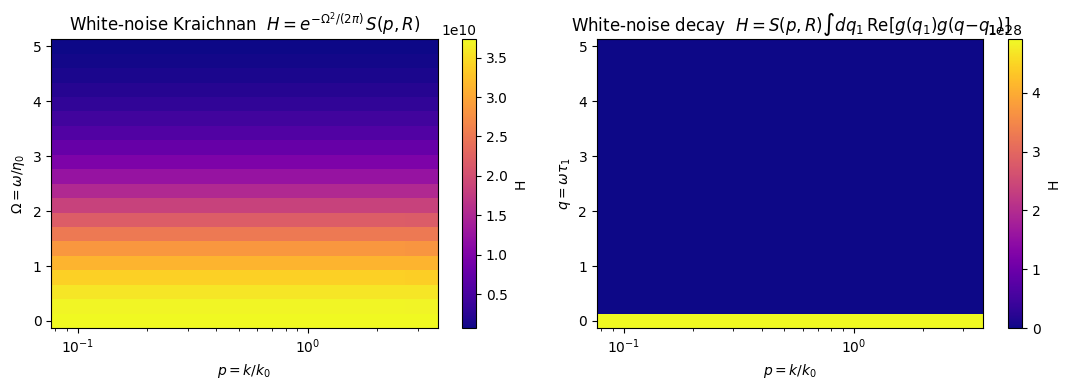

In [85]:
ps_wh      = np.logspace(-1, 0.5, 10)
Omegas_wh  = np.linspace(0.0, 5.0, 20)  # Omega = omega/eta0  (Kraichnan)
qs_wh      = np.linspace(0.0, 5.0, 20)  # q = omega*tau1      (decay)
R_wh_grid  = 1e4
eps_abs_wh = 1e-4
eps_rel_wh = 1e-3
n_pts_wh   = 200

status_wh = LiveStatusLogger(
    prefix='wh-grid', every_seconds=1.0,
    rank=0, root_only=True,
)

# Model 5: White-noise Kraichnan
H_wh_kraichnan = H_white_kraichnan_grid(
    ps_wh, Omegas_wh,
    R=R_wh_grid, epsabs=eps_abs_wh, epsrel=eps_rel_wh,
    status=status_wh,
)
print(f'H_white_kraichnan_grid shape: {H_wh_kraichnan.shape}')

# Model 6: White-noise decay
H_wh_decay = H_white_decay_grid(
    ps_wh, qs_wh,
    R=R_wh_grid, epsabs=eps_abs_wh, epsrel=eps_rel_wh,
    n_points=n_pts_wh,
    status=status_wh,
)
print(f'H_white_decay_grid     shape: {H_wh_decay.shape}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

pcm1 = ax1.pcolormesh(ps_wh, Omegas_wh, H_wh_kraichnan, shading='auto', cmap='plasma')
ax1.set_xscale('log')
ax1.set_xlabel(r'$p = k/k_0$')
ax1.set_ylabel(r'$\Omega = \omega/\eta_0$')
ax1.set_title(r'White-noise Kraichnan  $H = e^{-\Omega^2/(2\pi)}\,S(p,R)$')
fig.colorbar(pcm1, ax=ax1, label='H')

pcm2 = ax2.pcolormesh(ps_wh, qs_wh, H_wh_decay, shading='auto', cmap='plasma')
ax2.set_xscale('log')
ax2.set_xlabel(r'$p = k/k_0$')
ax2.set_ylabel(r'$q = \omega\tau_1$')
ax2.set_title(r'White-noise decay  $H = S(p,R)\int dq_1\,\mathrm{Re}[g(q_1)g(q{-}q_1)]$')
fig.colorbar(pcm2, ax=ax2, label='H')

fig.tight_layout()
plt.show()

## 8. All-model comparison — frequency spectra at fixed $p$

We evaluate $H(p_0, \cdot)$ vs the respective frequency variable for all six models
at **300 log-spaced points** in $[10^{-4}, 10]$.

**Parallelisation strategy:**
- *Model 1* (`H_pq`): `multiprocessing.Pool` — one worker per $q$ value.
- *Model 2* (`H_pq_decaying`): `H_pq_decaying_grid([p_0], freq_vals, processes=N)` —
  distributes 300 $(q, p_0)$ tasks across $N$ workers.
- *Model 3* (`H_delta_k_kraichnan`): fully vectorised via `H_delta_k_kraichnan_grid`, no loop.
- *Model 4* (`H_delta_k_decay`): `H_delta_k_decay_grid` — temporal conv once per $q$,
  broadcast over $p$.
- *Model 5* (`H_white_kraichnan`): `H_white_kraichnan_grid` — spatial $S(p_0,R)$
  precomputed once, Gaussian factor is vectorised.
- *Model 6* (`H_white_decay`): `H_white_decay_grid` — outer product $S(p_0)\otimes C(q)$.

Set `n_workers` to the number of physical CPU cores available.

In [86]:
import hashlib
import json as _json
import multiprocessing

# ── Grid definition ───────────────────────────────────────────────────────────
p0        = 0          # aeroacoustic (p→0) limit for Kolmogorov models
p_dk      = 1e-4       # small nonzero p for delta-k models (require p > 0)
                       # still in the aeroacoustic limit (p << k0=1)
M_cmp     = 0.1
R_cmp     = 1e3
k0_cmp    = 1.0
n_freq    = 300
freq_max  = 10.0
n_workers = 8          # set to physical CPU core count
freq_vals = np.logspace(-4, np.log10(freq_max), n_freq)

# ── Per-model integration settings ────────────────────────────────────────────
eps_abs_m1      = 5e-4
eps_rel_m1      = 3e-3

eps_abs_m2      = 2e-3
eps_rel_m2      = 1e-2
conv_method_m2  = 'trapz'
conv_points_m2  = 32
integ_method_m2 = 'sampled'
x_pts_m2        = 10
y_pts_m2        = 10

n_pts_m4        = 200   # convolution grid points for delta-k decay

eps_abs_wh      = 1e-4
eps_rel_wh      = 1e-3
n_pts_m6        = 200   # convolution grid points for white-noise decay

# ── Cache key: SHA-1 of all result-affecting parameters ───────────────────────
# Any parameter change produces a new hash ⇒ new filename ⇒ fresh computation.
_cache_params = dict(
    p0=p0, p_dk=p_dk, M=M_cmp, R=R_cmp, k0=k0_cmp,
    n_freq=n_freq, freq_max=freq_max,
    eps_abs_m1=eps_abs_m1, eps_rel_m1=eps_rel_m1,
    eps_abs_m2=eps_abs_m2, eps_rel_m2=eps_rel_m2,
    conv_method_m2=conv_method_m2, conv_points_m2=conv_points_m2,
    integ_method_m2=integ_method_m2, x_pts_m2=x_pts_m2, y_pts_m2=y_pts_m2,
    n_pts_m4=n_pts_m4,
    eps_abs_wh=eps_abs_wh, eps_rel_wh=eps_rel_wh, n_pts_m6=n_pts_m6,
)
_cache_hash   = hashlib.sha1(
    _json.dumps(_cache_params, sort_keys=True).encode()
).hexdigest()[:10]
cache_path_s8 = os.path.join(out_dir, f'all_models_s8_{_cache_hash}.npz')

print('Parameters hash:', _cache_hash)
print('Cache path     :', cache_path_s8)
print('Cache exists   :', os.path.exists(cache_path_s8))


Parameters hash: b361bf0bb3
Cache path     : /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/all_models_s8_b361bf0bb3.npz
Cache exists   : True


In [87]:
# ── Load from cache if it exists for current parameters ──────────────────────────
if os.path.exists(cache_path_s8):
    _d = np.load(cache_path_s8)
    assert np.allclose(_d['freq_vals'], freq_vals), \
        'freq_vals mismatch: cache was built with different n_freq / freq_max'
    H_m1 = _d['H_m1']
    H_m2 = _d['H_m2']
    H_m3 = _d['H_m3']
    H_m4 = _d['H_m4']
    H_m5 = _d['H_m5']
    H_m6 = _d['H_m6']
    print(f'Loaded from cache: {cache_path_s8}')

else:
    print(f'No cache for hash {_cache_hash!r} — computing all models...')

    # ───────────────────────────────────────────────────────────────────────────────
    # Model 1: H_pq — multiprocessing.Pool, one task per q value
    # ───────────────────────────────────────────────────────────────────────────────
    def _task_H_pq(args):
        """Top-level worker so multiprocessing can pickle it."""
        q, p, M, R, k0, epsabs, epsrel = args
        return H_pq(p, q, M=M, R=R, k0=k0, epsabs=epsabs, epsrel=epsrel)

    tasks_m1 = [
        (q, p0, M_cmp, R_cmp, k0_cmp, eps_abs_m1, eps_rel_m1)
        for q in freq_vals
    ]
    status_m1 = LiveStatusLogger(
        prefix='m1-stationary', every_seconds=3.0,
        rank=0, root_only=True,
    )
    status_m1(
        f'H_pq  {n_freq} pts  p={p0}  M={M_cmp}  R={R_cmp}  k0={k0_cmp}'
        f'  epsabs={eps_abs_m1}  epsrel={eps_rel_m1}  workers={n_workers}',
        force=True,
    )
    t0 = time.perf_counter()
    with multiprocessing.Pool(processes=n_workers) as pool:
        H_m1 = np.array(pool.map(_task_H_pq, tasks_m1))
    status_m1(f'done  {time.perf_counter() - t0:.1f} s', force=True)

    # ───────────────────────────────────────────────────────────────────────────────
    # Model 2: H_pq_decaying — grid with processes=N
    # ───────────────────────────────────────────────────────────────────────────────
    status_m2 = LiveStatusLogger(
        prefix='m2-decaying', every_seconds=3.0,
        rank=0, root_only=True,
    )
    t0 = time.perf_counter()
    H_m2 = H_pq_decaying_grid(
        [p0], freq_vals,
        M=M_cmp, R=R_cmp, k0=k0_cmp,
        epsabs=eps_abs_m2, epsrel=eps_rel_m2,
        verbose=False,
        convolution_method=conv_method_m2, convolution_points=conv_points_m2,
        integration_method=integ_method_m2, x_points=x_pts_m2, y_points=y_pts_m2,
        status=status_m2, log_points=False,
        use_mpi=False, processes=n_workers,
    )[:, 0]
    status_m2(f'done  {time.perf_counter() - t0:.1f} s', force=True)

    # ───────────────────────────────────────────────────────────────────────────────
    # Model 3: H_delta_k_kraichnan — fully vectorised
    # ───────────────────────────────────────────────────────────────────────────────
    status_m3 = LiveStatusLogger(
        prefix='m3-dk-kraichnan', every_seconds=0.0,
        rank=0, root_only=True,
    )
    status_m3(
        f'H_delta_k_kraichnan_grid  {n_freq} pts  p={p_dk}  (vectorised)',
        force=True,
    )
    t0 = time.perf_counter()
    H_m3 = H_delta_k_kraichnan_grid([p_dk], freq_vals)[:, 0]
    status_m3(f'done  {time.perf_counter() - t0:.4f} s', force=True)

    # ───────────────────────────────────────────────────────────────────────────────
    # Model 4: H_delta_k_decay — conv once per q, broadcast over p
    # ───────────────────────────────────────────────────────────────────────────────
    status_m4 = LiveStatusLogger(
        prefix='m4-dk-decay', every_seconds=2.0,
        rank=0, root_only=True,
    )
    t0 = time.perf_counter()
    H_m4 = H_delta_k_decay_grid(
        [p_dk], freq_vals,
        n_points=n_pts_m4,
        status=status_m4,
    )[:, 0]
    status_m4(f'done  {time.perf_counter() - t0:.1f} s', force=True)

    # ───────────────────────────────────────────────────────────────────────────────
    # Model 5: H_white_kraichnan — S(p0, R) precomputed once
    # ───────────────────────────────────────────────────────────────────────────────
    status_m5 = LiveStatusLogger(
        prefix='m5-white-kraichnan', every_seconds=2.0,
        rank=0, root_only=True,
    )
    t0 = time.perf_counter()
    H_m5 = H_white_kraichnan_grid(
        [p0], freq_vals,
        R=R_cmp, epsabs=eps_abs_wh, epsrel=eps_rel_wh,
        status=status_m5,
    )[:, 0]
    status_m5(f'done  {time.perf_counter() - t0:.1f} s', force=True)

    # ───────────────────────────────────────────────────────────────────────────────
    # Model 6: H_white_decay — outer product S(p0) ⊗ C(q)
    # ───────────────────────────────────────────────────────────────────────────────
    status_m6 = LiveStatusLogger(
        prefix='m6-white-decay', every_seconds=2.0,
        rank=0, root_only=True,
    )
    t0 = time.perf_counter()
    H_m6 = H_white_decay_grid(
        [p0], freq_vals,
        R=R_cmp, epsabs=eps_abs_wh, epsrel=eps_rel_wh,
        n_points=n_pts_m6,
        status=status_m6,
    )[:, 0]
    status_m6(f'done  {time.perf_counter() - t0:.1f} s', force=True)

    # ── Save ───────────────────────────────────────────────────────────────────────────
    np.savez(
        cache_path_s8,
        freq_vals=freq_vals,
        H_m1=H_m1, H_m2=H_m2, H_m3=H_m3,
        H_m4=H_m4, H_m5=H_m5, H_m6=H_m6,
        params=_json.dumps(_cache_params),
    )
    print(f'Saved: {cache_path_s8}')

print(f'freq_vals: {n_freq} pts in [{freq_vals[0]:.2e}, {freq_vals[-1]:.2e}]')
print('H shapes:', H_m1.shape, H_m2.shape, H_m3.shape, H_m4.shape, H_m5.shape, H_m6.shape)


Loaded from cache: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/all_models_s8_b361bf0bb3.npz
freq_vals: 300 pts in [1.00e-04, 1.00e+01]
H shapes: (300,) (300,) (300,) (300,) (300,) (300,)


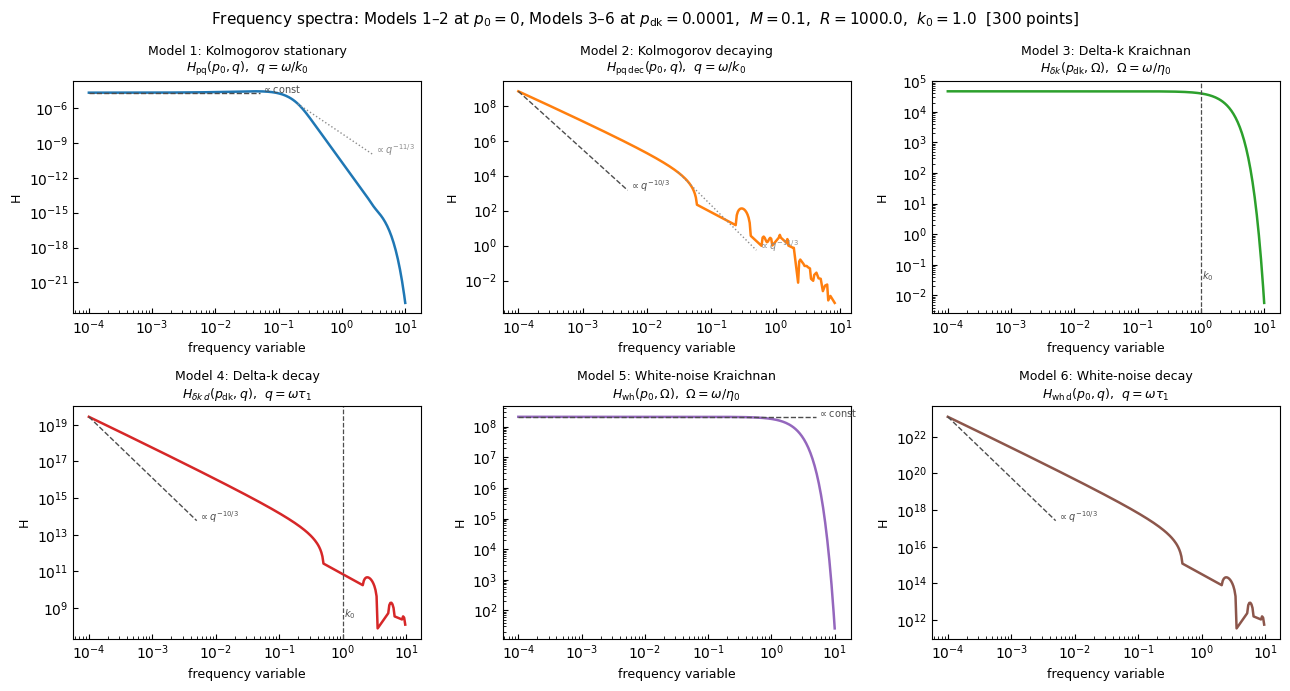

Saved: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/all4_comparison.pdf


In [88]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=False)

data = [
    (H_m1, 'C0', r'Model 1: Kolmogorov stationary',
     r'$H_{\rm pq}(p_0,q)$,  $q=\omega/k_0$'),
    (H_m2, 'C1', r'Model 2: Kolmogorov decaying',
     r'$H_{\rm pq\,dec}(p_0,q)$,  $q=\omega/k_0$'),
    (H_m3, 'C2', r'Model 3: Delta-k Kraichnan',
     r'$H_{\delta k}(p_{\rm dk},\Omega)$,  $\Omega=\omega/\eta_0$'),
    (H_m4, 'C3', r'Model 4: Delta-k decay',
     r'$H_{\delta k\,d}(p_{\rm dk},q)$,  $q=\omega\tau_1$'),
    (H_m5, 'C4', r'Model 5: White-noise Kraichnan',
     r'$H_{\rm wh}(p_0,\Omega)$,  $\Omega=\omega/\eta_0$'),
    (H_m6, 'C5', r'Model 6: White-noise decay',
     r'$H_{\rm wh\,d}(p_0,q)$,  $q=\omega\tau_1$'),
]
_slope_specs = [
    # (slope_lo, slope_hi, q_lo_range, q_hi_range, note_lo, note_hi)
    # M1 stationary Kraichnan: H is FLAT at low q (temporal correlator saturates)
    ( 0,    -11/3, (1e-4, 5e-2), (2e-1, 3e0),
      r'$\propto{\rm const}$', r'$\propto q^{-11/3}$'),
    # M2 decaying Kraichnan: |g(z)|^2 ~ z^{-10/3} as z->0 => H ~ q^{-10/3}
    (-10/3, -11/3, (1e-4, 5e-3), (3e-2, 5e-1),
      r'$\propto q^{-10/3}$', r'$\propto q^{-11/3}$'),
    # M3 delta-k Kraichnan: marker only (flat then sharp cutoff at k0)
    (None, None, None, None, None, None),
    # M4 delta-k decay: same IR divergence as M2 from decaying kernel
    (-10/3, None, (1e-4, 5e-3), None,
      r'$\propto q^{-10/3}$', None),
    # M5 white Kraichnan: H is FLAT at low Omega (all k contribute, temporal saturates)
    ( 0,    None,  (1e-4, 5e0), None,
      r'$\propto{\rm const}$', None),
    # M6 white decay: same IR divergence as M2/M4 from decaying kernel
    (-10/3, None,  (1e-4, 5e-3), None,
      r'$\propto q^{-10/3}$', None),
]
for ax, (H_vals, color, title, subtitle), sspec in zip(axes.flatten(), data, _slope_specs):
    mask = H_vals > 0
    ax.loglog(freq_vals[mask], H_vals[mask], color=color, lw=1.8)
    ax.set_title(f'{title}\n{subtitle}', fontsize=9)
    ax.set_xlabel('frequency variable', fontsize=9)
    ax.set_ylabel('H', fontsize=9)
    ax.tick_params(which='both', direction='in')

    s_lo, s_hi, r_lo, r_hi, lbl_lo, lbl_hi = sspec

    # Guide slopes for Kolmogorov + white-noise models
    if s_lo is not None and mask.any():
        _qrng = np.array(r_lo)
        _idx  = np.searchsorted(freq_vals[mask], r_lo[0])
        _idx  = min(_idx, mask.sum() - 1)
        _f0   = freq_vals[mask][_idx]
        _H0   = H_vals[mask][_idx]
        ax.loglog(_qrng, _H0 * (_qrng / _f0) ** s_lo,
                  color='0.3', lw=1.0, ls='--')
        ax.text(_qrng[1] * 1.1, _H0 * (_qrng[1] / _f0) ** s_lo,
                lbl_lo, fontsize=7, color='0.3')
    if s_hi is not None and mask.any():
        _qrng = np.array(r_hi)
        _idx  = np.searchsorted(freq_vals[mask], r_hi[0])
        _idx  = min(_idx, mask.sum() - 1)
        _f0   = freq_vals[mask][_idx]
        _H0   = H_vals[mask][_idx]
        ax.loglog(_qrng, _H0 * (_qrng / _f0) ** s_hi,
                  color='0.55', lw=1.0, ls=':')
        ax.text(_qrng[1] * 1.1, _H0 * (_qrng[1] / _f0) ** s_hi,
                lbl_hi, fontsize=7, color='0.55')

    # Vertical marker at the delta-k injection frequency (k0_cmp = 1)
    if title.startswith('Model 3') or title.startswith('Model 4'):
        ax.axvline(k0_cmp, color='0.3', lw=0.9, ls='--')
        ax.text(k0_cmp * 1.05, ax.get_ylim()[0] * 10 if ax.get_ylim()[0] > 0 else 1e-10,
                r'$k_0$', fontsize=7, color='0.3', va='bottom')

fig.suptitle(
    fr'Frequency spectra: Models 1–2 at $p_0={p0}$, Models 3–6 at $p_{{\rm dk}}={p_dk}$,  '
    fr'$M={M_cmp}$,  $R={R_cmp}$,  $k_0={k0_cmp}$  [{n_freq} points]',
    fontsize=11,
)
fig.tight_layout()
plt.show()

cmp_pdf = os.path.join(out_dir, 'all4_comparison.pdf')
fig.savefig(cmp_pdf)
print(f'Saved: {cmp_pdf}')


## 9. Save and reload a grid (.npz)

In [89]:
save_path = os.path.join(out_dir, 'demo_grid.npz')
np.savez(
    save_path,
    ps=ps_kol,
    qs=qs_kol,
    H_stationary=H_stationary,
    H_decaying=H_decaying,
)
print(f'Saved: {save_path}')

data = np.load(save_path)
assert np.allclose(data['ps'], ps_kol),             'ps mismatch'
assert np.allclose(data['qs'], qs_kol),             'qs mismatch'
assert np.allclose(data['H_stationary'], H_stationary), 'H_stat mismatch'
assert np.allclose(data['H_decaying'],  H_decaying),    'H_dec mismatch'
print('Round-trip verification passed.')

Saved: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/demo_grid.npz
Round-trip verification passed.


## 10. Library plotting helpers

`plot_spectra_M_analytic(M_list, qmin, qmax, nq, out_png, R)` and
`plot_gogoberidze_2007_figure1(M_list, qmin, qmax, nq, R, k0, out_png, epsabs, epsrel)`
are thin wrappers that produce publication-ready PDF/PNG files.

Wrote /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/demo_analytic_Ms1.00em02-1.00em01-1.00ep00_R1.00ep04.png


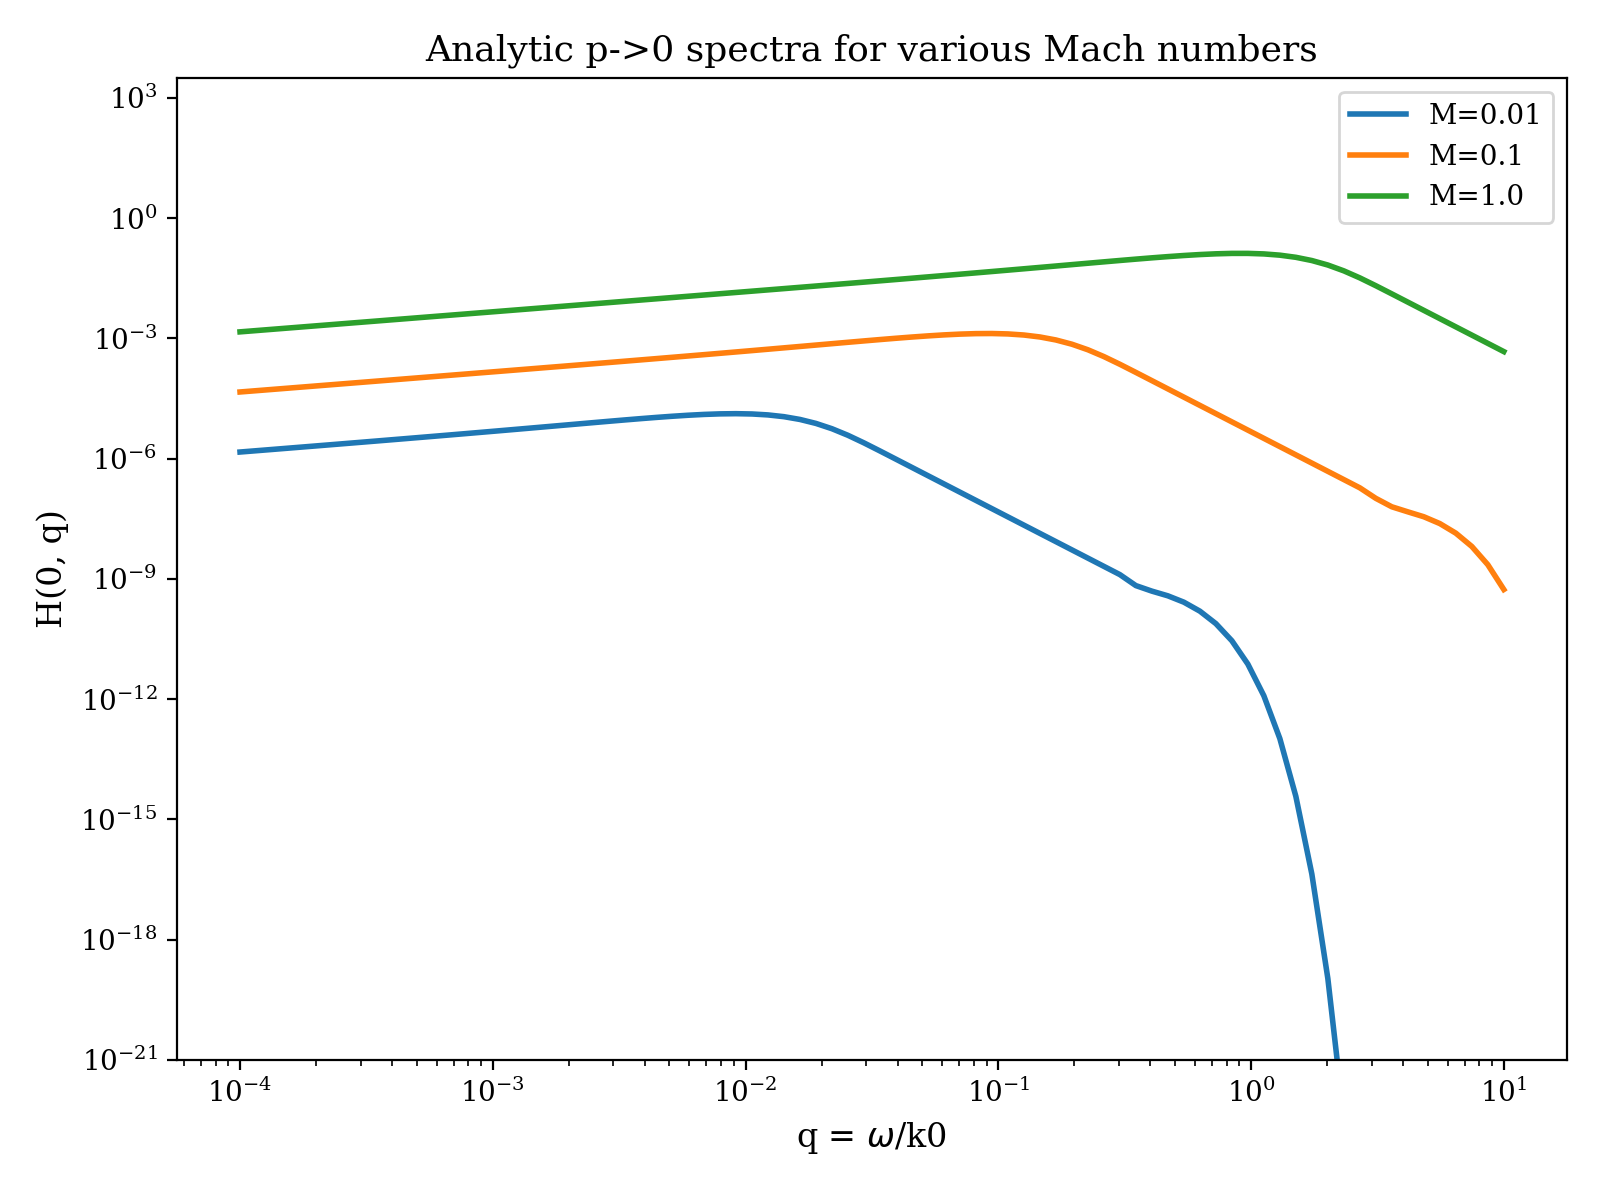

In [90]:
M_helper   = [0.01, 0.1, 1.0]
R_helper   = 1e4
nq_helper  = 80
qmin_helper = 1e-4
qmax_helper = 1e1

out_analytic_png = os.path.join(out_dir, 'demo_analytic.png')
plot_spectra_M_analytic(
    M_helper,
    qmin=qmin_helper,
    qmax=qmax_helper,
    nq=nq_helper,
    out_png=out_analytic_png,
    R=R_helper,
)

# Reconstruct the tagged filename the helper writes
def _ptag(v):
    return f'{v:.2e}'.replace('+', 'p').replace('-', 'm')

mlist_str = '-'.join([_ptag(M) for M in M_helper])
rstr = _ptag(R_helper)
base, ext = os.path.splitext(out_analytic_png)
actual_png = f'{base}_Ms{mlist_str}_R{rstr}{ext}'

if os.path.exists(actual_png):
    display(Image(filename=actual_png))
else:
    print(f'Expected: {actual_png}')
    pngs = sorted([f for f in os.listdir(out_dir) if 'demo_analytic' in f])
    for fn in pngs:
        display(Image(filename=os.path.join(out_dir, fn)))

## 11. Stationary turbulence — actual GW energy density $h^2\Omega_{\rm GW}$

### Cosmological conversion chain

The dimensionless spectral function $H(p,q)$ computed by `H_pq` is promoted to
observables through two steps.

**Step 1 — characteristic strain** (Gogoberidze 2007, Eq. after Fig. 1):
$$h_c(f) = h_{\rm norm}\cdot M^{3/2}
\left(\frac{g_*}{100}\right)^{-1/3}
\left(\frac{\gamma}{0.01}\right)^{3/2}
\left(\frac{\zeta}{0.01}\right)^{1/2}
\sqrt{q\cdot H(q,q)}$$
with $h_{\rm norm} = 1.62\times10^{-18}$.

**Step 2 — dimensionless energy density** (standard relation, $c=1$):
$$h^2\Omega_{\rm GW}(f) = \frac{2\pi^2}{3\,H_{100}^2}\,f^2\,h_c^2(f)$$
with $H_{100} = 100\,{\rm km\,s^{-1}\,Mpc^{-1}} = 3.24\times10^{-18}\,{\rm Hz}$.

**Physical frequency today** (after redshifting from production temperature $T_*$):
$$f[{\rm Hz}] = f_{\rm norm}\cdot q
\left(\frac{g_*}{100}\right)^{1/6}
\left(\frac{\gamma}{0.01}\right)^{-1}
\left(\frac{T_*}{100\,{\rm GeV}}\right)$$
with $f_{\rm norm} = 1.55\times10^{-3}\,{\rm Hz}$.

### Gogoberidze 2007 fiducial parameter values

| Symbol | Value | Meaning |
|---|---|---|
| $g_*$ | 100 | effective relativistic d.o.f. at GW production |
| $T_*$ | 100 GeV | temperature at GW production (EW phase transition) |
| $\gamma$ | 0.01 | turbulence injection rate / $H_*$ |
| $\zeta$ | 0.01 | fraction of plasma energy converted to GWs |
| $M$ | 0.01, 0.1, 1.0 | rms Mach number |
| $R$ | $10^4$ | inertial-range ratio $k_{\max}/k_0$ |

With all ratios equal to 1 (standard values), the prefactors reduce to 1
and $f = 1.55\times10^{-3}\cdot q$ Hz,\; $h_c = 1.62\times10^{-18}\cdot M^{3/2}\sqrt{q H}$.

In [91]:
import hashlib
import json as _json

# ── Gogoberidze 2007 cosmological parameter values ────────────────────────────
g_star   = 100.0      # effective relativistic d.o.f. at GW production
T_star   = 100.0      # GeV, temperature at GW production
gamma    = 0.01       # turbulence injection rate / H_*
zeta     = 0.01       # GW source efficiency
H100     = 3.24e-18   # Hz, H_0 / h_0  (h_0 = 1, 100 km/s/Mpc)

# Gogoberidze 2007 dimensionful conversion constants
f_norm   = 1.55e-3    # Hz, f = f_norm * q * (g*/100)^{1/6} * (gamma/0.01)^{-1} * (T*/100 GeV)
h_norm   = 1.62e-18   # h_c = h_norm * M^{3/2} * (g*/100)^{-1/3} * ... * sqrt(q*H)

def f_phys(q_arr, g_star=g_star, gamma=gamma, T_star=T_star):
    """Physical GW frequency today [Hz] from dimensionless q = omega/k_0."""
    return (f_norm
            * (g_star / 100) ** ( 1/6)
            * (gamma  / 0.01) ** (-1)
            * (T_star / 100)
            * q_arr)

def h_c_strain(q_arr, H_arr, M_val,
               g_star=g_star, gamma=gamma, zeta=zeta):
    """Characteristic GW strain h_c from H(q,q)."""
    val = np.where(q_arr * H_arr > 0, q_arr * H_arr, np.nan)
    return (h_norm
            * M_val ** 1.5
            * (g_star / 100) ** (-1/3)
            * (gamma  / 0.01) ** ( 1.5)
            * (zeta   / 0.01) ** ( 0.5)
            * np.sqrt(val))

def omega_gw_h2(f_arr, hc_arr, H100=H100):
    """Dimensionless GW energy density h^2 * Omega_GW."""
    return (2 * np.pi**2 / 3) * (f_arr / H100) ** 2 * hc_arr ** 2

# ── Spectral grid parameters ──────────────────────────────────────────────────
M_list_s11   = [0.01, 0.1, 1.0]
nq_s11       = 50
q_min_s11    = 1e-5
q_max_s11    = 64.0
R_s11        = 1e4
k0_s11       = 1.0
eps_abs_s11  = 1e-4
eps_rel_s11  = 1e-3
qs_s11       = np.logspace(np.log10(q_min_s11), np.log10(q_max_s11), nq_s11)

# ── Cache key ─────────────────────────────────────────────────────────────────
_s11_params = dict(
    M_list=M_list_s11, nq=nq_s11,
    q_min=q_min_s11, q_max=q_max_s11,
    R=R_s11, k0=k0_s11,
    eps_abs=eps_abs_s11, eps_rel=eps_rel_s11,
)
_s11_hash    = hashlib.sha1(
    _json.dumps(_s11_params, sort_keys=True).encode()
).hexdigest()[:10]
cache_s11    = os.path.join(out_dir, f'gogo_stationary_{_s11_hash}.npz')

print('Cache path:', cache_s11)
print('Exists    :', os.path.exists(cache_s11))


Cache path: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/gogo_stationary_836abd92f1.npz
Exists    : True


In [92]:
if os.path.exists(cache_s11):
    _d = np.load(cache_s11)
    assert np.allclose(_d['qs'], qs_s11), 'qs mismatch: cache built with different grid'
    H_exact_s11 = _d['H_exact']   # H_pq(q, q) for each M
    H_aero_s11  = _d['H_aero']    # H_k0_analytic(q) for each M
    print(f'Loaded from cache: {cache_s11}')
else:
    print(f'No cache ({_s11_hash!r}) — computing H_pq and H_k0_analytic...')
    H_exact_s11 = np.zeros((len(M_list_s11), nq_s11))
    H_aero_s11  = np.zeros((len(M_list_s11), nq_s11))
    for m_idx, M in enumerate(M_list_s11):
        status_s11 = LiveStatusLogger(
            prefix=f's11-M{M}', every_seconds=3.0,
            rank=0, root_only=True,
        )
        for i, q in enumerate(qs_s11):
            H_exact_s11[m_idx, i] = H_pq(
                q, q,
                M=M, R=R_s11, k0=k0_s11,
                epsabs=eps_abs_s11, epsrel=eps_rel_s11,
            )
            H_aero_s11[m_idx, i] = H_k0_analytic(
                q,
                M=M, k0=k0_s11, R=R_s11,
            )
            status_s11(f'q={q:.3e}  H_exact={H_exact_s11[m_idx, i]:.3e}  '
                       f'H_aero={H_aero_s11[m_idx, i]:.3e}')
        status_s11(f'done M={M}', force=True)
    np.savez(
        cache_s11,
        qs=qs_s11,
        H_exact=H_exact_s11,
        H_aero=H_aero_s11,
        params=_json.dumps(_s11_params),
    )
    print(f'Saved: {cache_s11}')


Loaded from cache: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/gogo_stationary_836abd92f1.npz


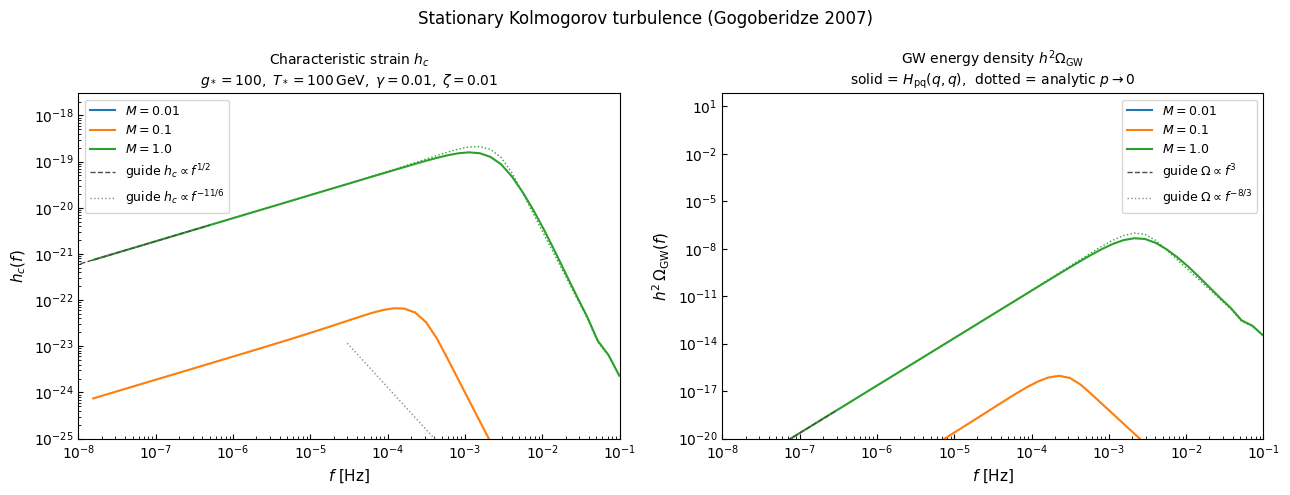

Saved: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/stationary_omega_gw.pdf


In [93]:
colors_s11 = {0.01: 'C0', 0.1: 'C1', 1.0: 'C2'}
f_arr_s11  = f_phys(
    qs_s11,
    g_star=g_star, gamma=gamma, T_star=T_star,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: characteristic strain (Gogoberidze normalised axes, sanity-check vs their Fig. 1)
ax_hc = axes[0]
for m_idx, M in enumerate(M_list_s11):
    hc_ex = h_c_strain(
        qs_s11, H_exact_s11[m_idx],
        M_val=M, g_star=g_star, gamma=gamma, zeta=zeta,
    )
    hc_an = h_c_strain(
        qs_s11, H_aero_s11[m_idx],
        M_val=M, g_star=g_star, gamma=gamma, zeta=zeta,
    )
    lbl = f'$M={M}$'
    ax_hc.loglog(f_arr_s11, hc_ex, color=colors_s11[M], lw=1.5, label=lbl)
    ax_hc.loglog(f_arr_s11, hc_an, color=colors_s11[M], lw=1.0, ls=':')

ax_hc.set_xlim(1e-8, 1e-1)
ax_hc.set_ylim(1e-25, 3e-18)  # floor shows M=0.01; ceiling clips guide overshoot
ax_hc.set_xlabel(r'$f$ [Hz]', fontsize=11)
ax_hc.set_ylabel(r'$h_c(f)$', fontsize=11)
ax_hc.set_title(
    r'Characteristic strain $h_c$' + '\n'
    fr'$g_*={g_star:.0f},\;T_*={T_star:.0f}\,{{\rm GeV}},\;'
    fr'\gamma={gamma},\;\zeta={zeta}$',
    fontsize=10,
)

# Guide slopes (h_c panel)
_f0_hc  = 1e-6    # anchor frequency for low-f causality slope
_hc_ref = h_c_strain(
    np.array([_f0_hc / f_norm]),
    H_k0_analytic(np.array([_f0_hc / f_norm]), M=1.0, k0=k0_s11, R=R_s11),
    M_val=1.0, g_star=g_star, gamma=gamma, zeta=zeta,
)[0]
_flo = np.array([3e-9, 5e-7])
ax_hc.loglog(_flo, np.where(np.isfinite(_hc_ref),
             _hc_ref * (_flo / _f0_hc) ** 0.5, np.nan),
             color='0.3', lw=1.0, ls='--', label=r'guide $h_c\propto f^{1/2}$')
_fhi = np.array([3e-5, 3e-3])
ax_hc.loglog(_fhi, np.where(np.isfinite(_hc_ref),
             _hc_ref * (_fhi / _f0_hc) ** (-11/6), np.nan),
             color='0.55', lw=1.0, ls=':', label=r'guide $h_c\propto f^{-11/6}$')
ax_hc.legend(fontsize=9)
ax_hc.tick_params(which='both', direction='in')

# Right: actual h^2 Omega_GW
ax_om = axes[1]
for m_idx, M in enumerate(M_list_s11):
    hc_ex = h_c_strain(
        qs_s11, H_exact_s11[m_idx],
        M_val=M, g_star=g_star, gamma=gamma, zeta=zeta,
    )
    hc_an = h_c_strain(
        qs_s11, H_aero_s11[m_idx],
        M_val=M, g_star=g_star, gamma=gamma, zeta=zeta,
    )
    om_ex = omega_gw_h2(f_arr_s11, hc_ex, H100=H100)
    om_an = omega_gw_h2(f_arr_s11, hc_an, H100=H100)
    lbl = f'$M={M}$'
    ax_om.loglog(f_arr_s11, om_ex, color=colors_s11[M], lw=1.5, label=lbl)
    ax_om.loglog(f_arr_s11, om_an, color=colors_s11[M], lw=1.0, ls=':')


# Guide slopes (Omega_GW panel)
_f0_om  = 2e-7
_om_ref = omega_gw_h2(
    _f0_om,
    h_c_strain(
        np.array([_f0_om / f_norm]),
        H_k0_analytic(np.array([_f0_om / f_norm]), M=1.0, k0=k0_s11, R=R_s11),
        M_val=1.0, g_star=g_star, gamma=gamma, zeta=zeta,
    )[0],
    H100=H100,
)
_flo_om = np.array([5e-9, 3e-7])
ax_om.loglog(_flo_om, _om_ref * (_flo_om / _f0_om) ** 3,
             color='0.3', lw=1.0, ls='--', label=r'guide $\Omega\propto f^3$')
_fhi_om = np.array([5e-5, 5e-3])
ax_om.loglog(_fhi_om, _om_ref * (_fhi_om / _f0_om) ** (-8/3),
             color='0.55', lw=1.0, ls=':', label=r'guide $\Omega\propto f^{-8/3}$')
ax_om.set_xlim(1e-8, 1e-1)
ax_om.set_ylim(1e-20, None)   # clip subnormal values (small-M high-q)
ax_om.set_xlabel(r'$f$ [Hz]', fontsize=11)
ax_om.set_ylabel(r'$h^2\,\Omega_{\rm GW}(f)$', fontsize=11)
ax_om.set_title(
    r'GW energy density $h^2\Omega_{\rm GW}$' + '\n'
    r'solid = $H_{\rm pq}(q,q)$,  dotted = analytic $p\to 0$',
    fontsize=10,
)
ax_om.legend(fontsize=9)
ax_om.tick_params(which='both', direction='in')

fig.suptitle('Stationary Kolmogorov turbulence (Gogoberidze 2007)', fontsize=12)
fig.tight_layout()
plt.show()

s11_pdf = os.path.join(out_dir, 'stationary_omega_gw.pdf')
fig.savefig(s11_pdf)
print(f'Saved: {s11_pdf}')


## 12. Decaying turbulence — physics and $h^2\Omega_{\rm GW}$

### What changes in decaying turbulence

In the **stationary (Kraichnan)** model the turbulent energy at each wavevector
is sustained forever by a forcing mechanism.  The two-time velocity correlator
decays as a Gaussian:
$$\langle v(\mathbf{k}, t_1)\,v(\mathbf{k}, t_2)^*\rangle
\propto \exp\!\left(-\tfrac{\pi}{4}(\eta_k|t_1-t_2|)^2\right)$$
The Fourier transform is Gaussian $\tilde v(\omega) \propto e^{-\omega^2/(2\eta_k^2)}$,
so the $\omega_1$ convolution integral in $H(p,q)$ can be done **analytically** via erfc.

In the **decaying** model the total turbulent energy decreases after the phase
transition.  The spectrum evolves as:
$$E(k, t) = E_0(k)\left(1 + \frac{t}{\tau_1}\right)^{-2/3}, \qquad t \ge 0$$
where $\tau_1 = (k_0 v_{\rm rms})^{-1}$ is the large-eddy turnover time and
$E_0(k) \propto k^{-5/3}$ is the initial Kolmogorov spectrum.

The velocity amplitude at wavenumber $k$ thus decays as:
$$v(\mathbf{k}, t) = v_0(\mathbf{k})\left(1 + \frac{t}{\tau_1}\right)^{-1/3}$$

The temporal Fourier transform of $(1 + t/\tau_1)^{-1/3}$ for $t \ge 0$ gives
the kernel $g(z)$ with $z = \omega\tau_1$ (from §1):
$$\tilde v(\mathbf{k}, \omega) = v_0(\mathbf{k})\,\tau_1\,g(\omega\tau_1)$$

Because $g(z)$ has a **power-law tail** $|g(z)| \sim |z|^{-5/3}$ at large $|z|$
(vs exponential for the Gaussian), the $\omega_1$ convolution
$\int dq_1\,\mathrm{Re}[g(q_1\sqrt{x}/M)\,g((q-q_1)\sqrt{y}/M)]$
must be done **numerically** using a cosine-spaced grid (`convolution_method='trapz'`).

### Expected spectral differences

| Feature | Stationary (Kraichnan) | Decaying |
|---|---|---|
| High-$f$ cutoff | Gaussian $\exp(-f^2/f_0^2)$ | Power-law $f^{-5/3}$ tail |
| Low-$f$ slope | $\Omega_{\rm GW} \propto f^3$ (causality) | same |
| Peak amplitude | lower (finite correlation time) | higher (extended emission) |
| Computational cost | fast (analytic conv.) | slow (numeric conv.) |

All else equal, the decaying spectrum is broader and peaks at lower amplitude
per unit source energy because the power-law decay distributes energy over
a wider frequency band.

*(Coarse settings below for speed; increase `nq_s12`, `conv_points_s12`,
`x_pts_s12`, `y_pts_s12` for publication quality.)*

In [94]:
# ── Spectral grid parameters ──────────────────────────────────────────────────
M_list_s12       = [0.1, 1.0]
nq_s12           = 24
q_min_s12        = 1e-4
q_max_s12        = 10.0
R_s12            = 1e3
k0_s12           = 1.0

# Stationary (H_pq) tolerances
eps_abs_stat_s12 = 1e-4
eps_rel_stat_s12 = 1e-3

# Decaying (H_pq_decaying) tolerances + integration settings
eps_abs_dec_s12  = 2e-3
eps_rel_dec_s12  = 1e-2
conv_method_s12  = 'trapz'
conv_points_s12  = 32
integ_method_s12 = 'sampled'
x_pts_s12        = 10
y_pts_s12        = 10

qs_s12 = np.logspace(np.log10(q_min_s12), np.log10(q_max_s12), nq_s12)

# ── Cache key (covers both stat + dec with their respective tolerances) ───────
_s12_params = dict(
    M_list=M_list_s12, nq=nq_s12,
    q_min=q_min_s12, q_max=q_max_s12,
    R=R_s12, k0=k0_s12,
    eps_abs_stat=eps_abs_stat_s12, eps_rel_stat=eps_rel_stat_s12,
    eps_abs_dec=eps_abs_dec_s12,   eps_rel_dec=eps_rel_dec_s12,
    conv_method=conv_method_s12,   conv_points=conv_points_s12,
    integ_method=integ_method_s12, x_pts=x_pts_s12, y_pts=y_pts_s12,
)
_s12_hash  = hashlib.sha1(
    _json.dumps(_s12_params, sort_keys=True).encode()
).hexdigest()[:10]
cache_s12  = os.path.join(out_dir, f'stat_vs_dec_{_s12_hash}.npz')

print('Cache path:', cache_s12)
print('Exists    :', os.path.exists(cache_s12))


Cache path: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/stat_vs_dec_682da30438.npz
Exists    : True


In [95]:
if os.path.exists(cache_s12):
    _d = np.load(cache_s12)
    assert np.allclose(_d['qs'], qs_s12), 'qs mismatch'
    H_stat_s12 = _d['H_stat']   # shape (len(M_list_s12), nq_s12)
    H_dec_s12  = _d['H_dec']
    print(f'Loaded from cache: {cache_s12}')

else:
    print(f'No cache ({_s12_hash!r}) — computing stationary + decaying diagonal H(q,q)...')
    H_stat_s12 = np.zeros((len(M_list_s12), nq_s12))
    H_dec_s12  = np.zeros((len(M_list_s12), nq_s12))

    # Worker function for Pool: computes one decaying diagonal point H(q,q)
    def _task_dec_diag(args):
        q, M, R, k0, ea, er, cm, cp, im, xp, yp = args
        return H_pq_decaying(
            q, q,
            M=M, R=R, k0=k0,
            epsabs=ea, epsrel=er,
            convolution_method=cm, convolution_points=cp,
            integration_method=im, x_points=xp, y_points=yp,
            status=None,
        )

    for m_idx, M in enumerate(M_list_s12):

        # ── Stationary: H_pq(q, q) ──────────────────────────────────────────────
        status_stat = LiveStatusLogger(
            prefix=f's12-stat-M{M}', every_seconds=3.0,
            rank=0, root_only=True,
        )
        status_stat(
            f'H_pq diagonal  {nq_s12} pts  M={M}  R={R_s12}  k0={k0_s12}'
            f'  epsabs={eps_abs_stat_s12}  epsrel={eps_rel_stat_s12}',
            force=True,
        )
        for i, q in enumerate(qs_s12):
            H_stat_s12[m_idx, i] = H_pq(
                q, q,
                M=M, R=R_s12, k0=k0_s12,
                epsabs=eps_abs_stat_s12, epsrel=eps_rel_stat_s12,
            )
            status_stat(f'q={q:.3e}  H={H_stat_s12[m_idx,i]:.3e}')
        status_stat('done', force=True)

        # ── Decaying: H_pq_decaying(q, q) via Pool ──────────────────────────────
        dec_args = [
            (q, M, R_s12, k0_s12,
             eps_abs_dec_s12, eps_rel_dec_s12,
             conv_method_s12, conv_points_s12,
             integ_method_s12, x_pts_s12, y_pts_s12)
            for q in qs_s12
        ]
        status_dec = LiveStatusLogger(
            prefix=f's12-dec-M{M}', every_seconds=3.0,
            rank=0, root_only=True,
        )
        status_dec(
            f'H_pq_decaying diagonal  {nq_s12} pts  M={M}  R={R_s12}  k0={k0_s12}'
            f'  conv={conv_method_s12}/{conv_points_s12}'
            f'  integ={integ_method_s12}/x{x_pts_s12}/y{y_pts_s12}'
            f'  workers=8',
            force=True,
        )
        t0 = time.perf_counter()
        with multiprocessing.Pool(processes=8) as pool:
            H_dec_s12[m_idx] = np.array(pool.map(_task_dec_diag, dec_args))
        status_dec(f'done  {time.perf_counter() - t0:.1f} s', force=True)

    np.savez(
        cache_s12,
        qs=qs_s12,
        H_stat=H_stat_s12,
        H_dec=H_dec_s12,
        params=_json.dumps(_s12_params),
    )
    print(f'Saved: {cache_s12}')


Loaded from cache: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/stat_vs_dec_682da30438.npz


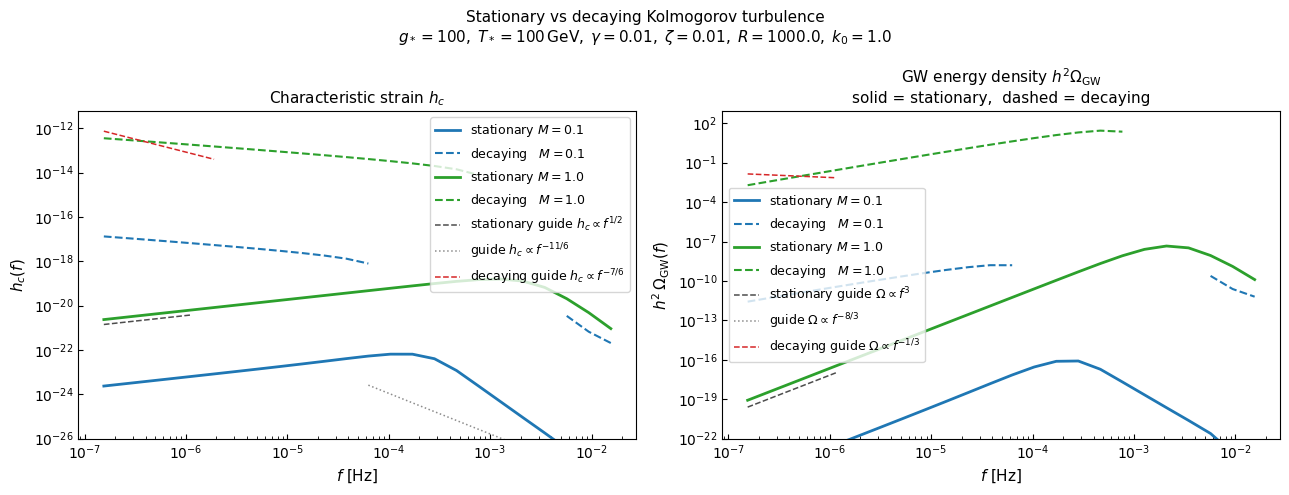

Saved: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/stat_vs_dec_omega_gw.pdf


In [96]:
colors_s12 = {0.1: 'C0', 1.0: 'C2'}
f_arr_s12  = f_phys(
    qs_s12,
    g_star=g_star, gamma=gamma, T_star=T_star,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: characteristic strain h_c
ax_hc = axes[0]
for m_idx, M in enumerate(M_list_s12):
    hc_stat = h_c_strain(
        qs_s12, H_stat_s12[m_idx],
        M_val=M, g_star=g_star, gamma=gamma, zeta=zeta,
    )
    hc_dec = h_c_strain(
        qs_s12, H_dec_s12[m_idx],
        M_val=M, g_star=g_star, gamma=gamma, zeta=zeta,
    )
    ax_hc.loglog(f_arr_s12, hc_stat, color=colors_s12[M], lw=2.0,
                 label=f'stationary $M={M}$')
    ax_hc.loglog(f_arr_s12, hc_dec,  color=colors_s12[M], lw=1.5, ls='--',
                 label=f'decaying   $M={M}$')

ax_hc.set_xlabel(r'$f$ [Hz]', fontsize=11)
ax_hc.set_ylabel(r'$h_c(f)$', fontsize=11)
ax_hc.set_title(r'Characteristic strain $h_c$', fontsize=11)
# Guide slopes (h_c panel)
# Stationary: h_c ~ f^{1/2} at low f (causality: h²Ω ~ f³)
_f0_hc31  = f_arr_s12[3]
_hc0_stat = h_c_strain(
    qs_s12[3:4], H_stat_s12[-1, 3:4],
    M_val=M_list_s12[-1], g_star=g_star, gamma=gamma, zeta=zeta,
)[0]
_flo_hc31 = np.array([f_arr_s12[0], f_arr_s12[4]])
ax_hc.loglog(_flo_hc31, 0.6 * _hc0_stat * (_flo_hc31 / _f0_hc31) ** 0.5,
             color='0.3', lw=1.1, ls='--',
             label=r'stationary guide $h_c\propto f^{1/2}$')
# High-f Kolmogorov falloff
_fhi_hc31 = np.array([f_arr_s12[12], f_arr_s12[-3]])
ax_hc.loglog(_fhi_hc31, 2.0 * _hc0_stat * (_fhi_hc31 / _f0_hc31) ** (-11/6),
             color='0.55', lw=1.1, ls=':',
             label=r'guide $h_c\propto f^{-11/6}$')
# Decaying: H ~ q^{-10/3} => h_c = sqrt(q*H) ~ q^{-7/6} ~ f^{-7/6}
_f0_dec31  = f_arr_s12[3]
_hc0_dec   = h_c_strain(
    qs_s12[3:4], H_dec_s12[-1, 3:4],
    M_val=M_list_s12[-1], g_star=g_star, gamma=gamma, zeta=zeta,
)[0]
_flo_dec31 = np.array([f_arr_s12[0], f_arr_s12[5]])
if np.isfinite(_hc0_dec) and _hc0_dec > 0:
    ax_hc.loglog(_flo_dec31, 0.6 * _hc0_dec * (_flo_dec31 / _f0_dec31) ** (-7/6),
                 color='C3', lw=1.1, ls='--',
                 label=r'decaying guide $h_c\propto f^{-7/6}$')
ax_hc.set_ylim(1e-26, None)   # clip subnormal values at large q
ax_hc.legend(fontsize=9)
ax_hc.tick_params(which='both', direction='in')

# Right: h^2 Omega_GW
ax_om = axes[1]
for m_idx, M in enumerate(M_list_s12):
    hc_stat = h_c_strain(
        qs_s12, H_stat_s12[m_idx],
        M_val=M, g_star=g_star, gamma=gamma, zeta=zeta,
    )
    hc_dec = h_c_strain(
        qs_s12, H_dec_s12[m_idx],
        M_val=M, g_star=g_star, gamma=gamma, zeta=zeta,
    )
    om_stat = omega_gw_h2(f_arr_s12, hc_stat, H100=H100)
    om_dec  = omega_gw_h2(f_arr_s12, hc_dec,  H100=H100)
    ax_om.loglog(f_arr_s12, om_stat, color=colors_s12[M], lw=2.0,
                 label=f'stationary $M={M}$')
    ax_om.loglog(f_arr_s12, om_dec,  color=colors_s12[M], lw=1.5, ls='--',
                 label=f'decaying   $M={M}$')

# Guide slopes (Omega_GW panel)
# Stationary causality: Omega ~ f³ at low f
_f0_s12   = f_arr_s12[3]
_om0_stat = omega_gw_h2(
    _f0_s12,
    h_c_strain(qs_s12[3:4], H_stat_s12[-1, 3:4],
               M_val=M_list_s12[-1], g_star=g_star, gamma=gamma, zeta=zeta)[0],
    H100=H100,
)
_flo_s12  = np.array([f_arr_s12[0], f_arr_s12[4]])
ax_om.loglog(_flo_s12, 0.3 * _om0_stat * (_flo_s12 / _f0_s12) ** 3,
             color='0.3', lw=1.1, ls='--',
             label=r'stationary guide $\Omega\propto f^3$')
_fhi_s12 = np.array([f_arr_s12[12], f_arr_s12[-3]])
ax_om.loglog(_fhi_s12, 2.0 * _om0_stat * (_fhi_s12 / _f0_s12) ** (-8/3),
             color='0.55', lw=1.1, ls=':',
             label=r'guide $\Omega\propto f^{-8/3}$')
# Decaying IR divergence: h_c ~ f^{-7/6} => Omega ~ f²*h_c² ~ f^{-7/3+2} = f^{-1/3}
_om0_dec = omega_gw_h2(
    _f0_s12,
    h_c_strain(qs_s12[3:4], H_dec_s12[-1, 3:4],
               M_val=M_list_s12[-1], g_star=g_star, gamma=gamma, zeta=zeta)[0],
    H100=H100,
)
if np.isfinite(_om0_dec) and _om0_dec > 0:
    ax_om.loglog(_flo_s12, 0.6 * _om0_dec * (_flo_s12 / _f0_s12) ** (-1/3),
                 color='C3', lw=1.1, ls='--',
                 label=r'decaying guide $\Omega\propto f^{-1/3}$')

ax_om.set_xlabel(r'$f$ [Hz]', fontsize=11)
ax_om.set_ylabel(r'$h^2\,\Omega_{\rm GW}(f)$', fontsize=11)
ax_om.set_title(
    r'GW energy density $h^2\Omega_{\rm GW}$' + '\n'
    r'solid = stationary,  dashed = decaying',
    fontsize=11,
)
ax_om.set_ylim(1e-22, None)   # clip subnormal / numerically unreliable values
ax_om.legend(fontsize=9)
ax_om.tick_params(which='both', direction='in')

_sup_line1 = 'Stationary vs decaying Kolmogorov turbulence'
_sup_line2 = (fr'$g_*={g_star:.0f},\;T_*={T_star:.0f}\,'
              fr'{{\rm GeV}},\;\gamma={gamma},\;'
              fr'\zeta={zeta},\;R={R_s12},\;k_0={k0_s12}$')
fig.suptitle(_sup_line1 + '\n' + _sup_line2, fontsize=11)
fig.tight_layout()
plt.show()

s12_pdf = os.path.join(out_dir, 'stat_vs_dec_omega_gw.pdf')
fig.savefig(s12_pdf)
print(f'Saved: {s12_pdf}')
